# Regularization and bias-variance

A degree-14 polynomial has enough flexibility to follow random variation in a small noisy sample. This notebook uses the same data split while changing the penalty, so the effect of regularization can be separated from the effect of changing the data.


## Ridge and lasso

Ridge adds `alpha * ||w||²` to the objective and shrinks coefficients continuously. Lasso adds `alpha * ||w||₁` and can set coefficients exactly to zero. Polynomial features are standardized before the penalty is applied; otherwise the numerical scale of a feature would influence the penalty.


selected ridge alpha: 0.00001
validation MSE at selected alpha: 0.0418
 unregularized test MSE: 0.1363
         ridge test MSE: 0.1087
         lasso test MSE: 0.0549


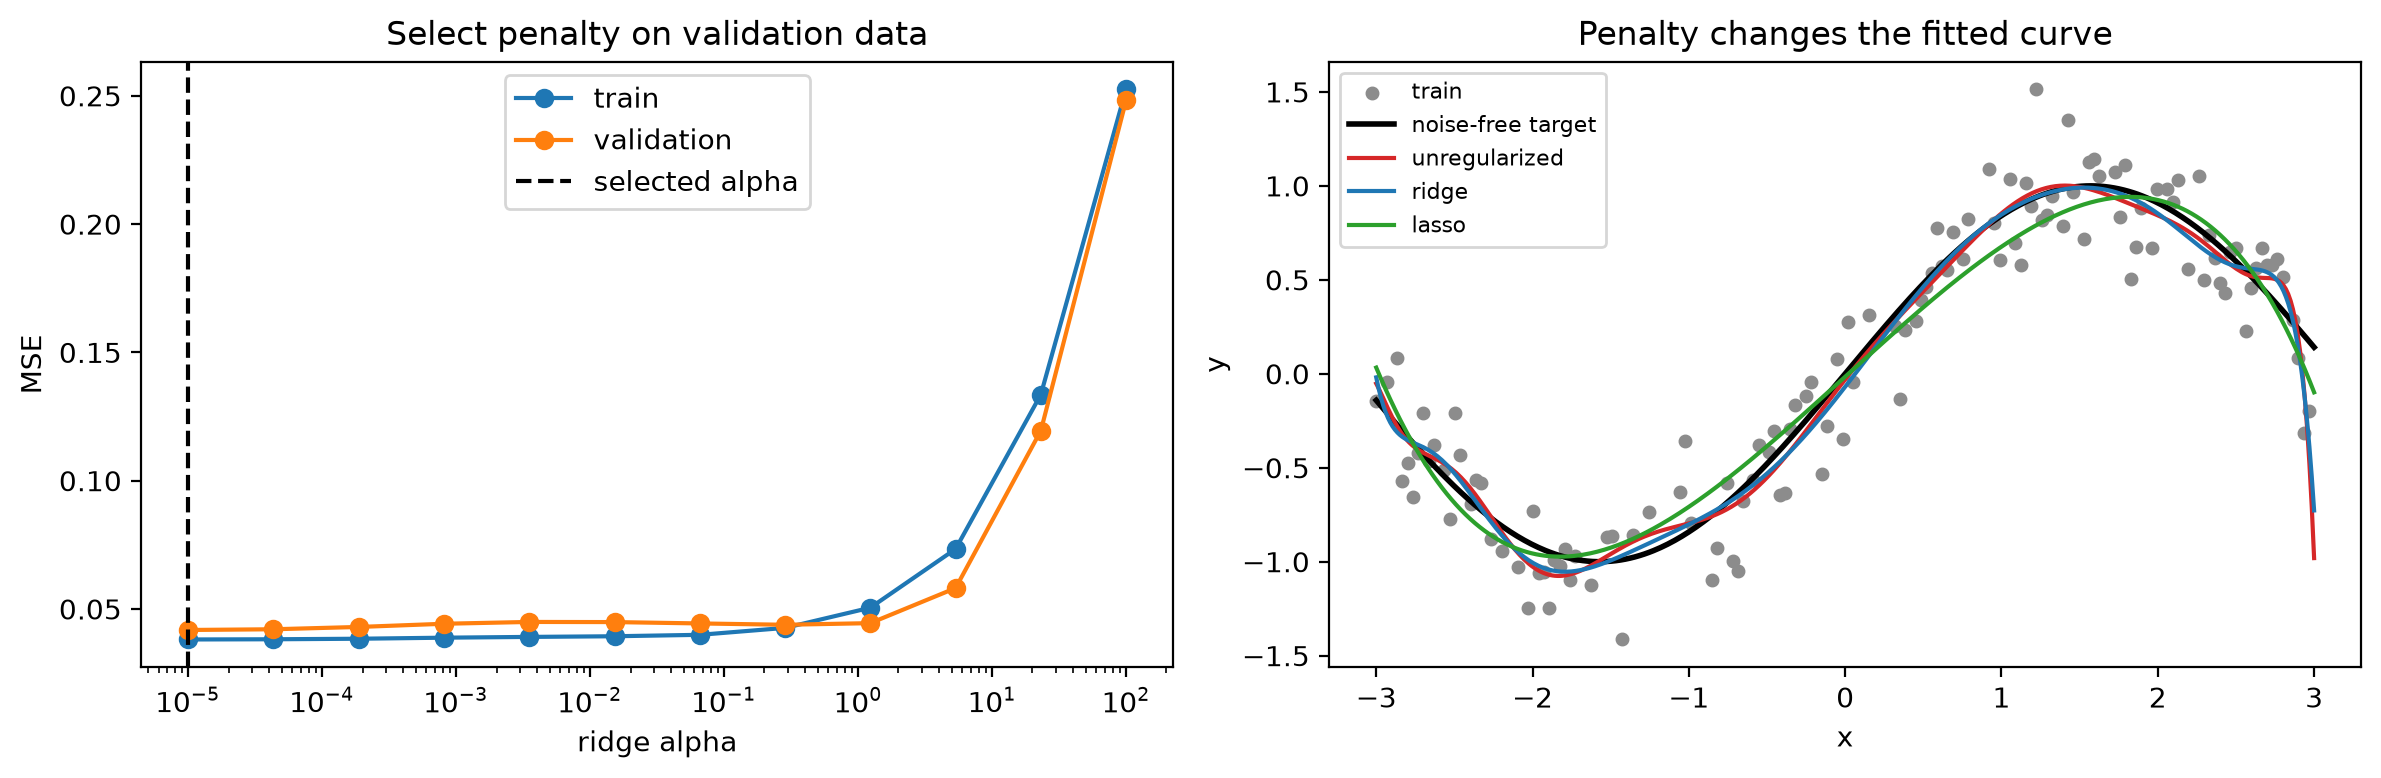

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

rng = np.random.default_rng(12)
x = np.linspace(-3, 3, 180)[:, None]
y = np.sin(x[:, 0]) + rng.normal(scale=0.22, size=len(x))
X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.30, random_state=5)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=5)

degree = 14
alphas = np.logspace(-5, 2, 12)
train_mse, val_mse = [], []
for alpha in alphas:
    ridge = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=alpha))
    ridge.fit(X_train, y_train)
    train_mse.append(mean_squared_error(y_train, ridge.predict(X_train)))
    val_mse.append(mean_squared_error(y_val, ridge.predict(X_val)))

best_alpha = alphas[np.argmin(val_mse)]
unregularized = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression()).fit(X_train, y_train)
ridge = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=best_alpha)).fit(X_train, y_train)
lasso = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=0.01, max_iter=20_000)).fit(X_train, y_train)

print(f'selected ridge alpha: {best_alpha:.5f}')
print(f'validation MSE at selected alpha: {min(val_mse):.4f}')
for name, model in [('unregularized', unregularized), ('ridge', ridge), ('lasso', lasso)]:
    print(f'{name:>14} test MSE: {mean_squared_error(y_test, model.predict(X_test)):.4f}')

grid = np.linspace(-3, 3, 400)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(alphas, train_mse, marker='o', label='train')
axes[0].semilogx(alphas, val_mse, marker='o', label='validation')
axes[0].axvline(best_alpha, color='black', linestyle='--', label='selected alpha')
axes[0].set(xlabel='ridge alpha', ylabel='MSE', title='Select penalty on validation data')
axes[0].legend()
axes[1].scatter(X_train, y_train, s=16, color='0.55', label='train')
axes[1].plot(grid, np.sin(grid[:, 0]), color='black', linewidth=2, label='noise-free target')
for name, model, color in [('unregularized', unregularized, 'tab:red'), ('ridge', ridge, 'tab:blue'), ('lasso', lasso, 'tab:green')]:
    axes[1].plot(grid, model.predict(grid), color=color, label=name)
axes[1].set(xlabel='x', ylabel='y', title='Penalty changes the fitted curve')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## Selecting the penalty

A range of ridge values is fitted on the training data. Training MSE generally favours a flexible curve, while validation MSE identifies a value that is more stable on unseen data. The selected ridge model, an unregularized polynomial, and a lasso model are then compared once on the test partition. The curve plot and the fitted functions show why the numerical comparison is not only about the smallest training error.
